# import Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc, confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# Hyperparameters and Global Variables

In [2]:
# Define hyperparameters and global constants
EMB_DIM = 32          # Embedding dimensionality
N_LAYERS = 2          # Number of LightGCN propagation layers
LR = 5e-3             # Learning rate
WEIGHT_DECAY = 1e-5   # Weight decay for optimizers
EPOCHS = 40           # Number of training epochs
BATCH_SIZE = 1024     # Batch size for training
NUM_NEG = 4           # Number of negative samples per positive in BPR training
LAMBDA_MSE = 0.0      # Weight for MSE loss (0 if rating is not used, treating as pure implicit)

# Threshold for considering an interaction "good" (for splitting into train/val/test)
GOOD_RATING_THRESHOLD = 0.0  # treat rating > 0 as positive interaction to recommend

# Paths (if running in Colab or local, adjust accordingly)
TRAIN_DATA_PATH = "otc_train.csv"  # path to training interaction data


# Data Loading & Preprocessing

In [3]:
# Load the dataset
df = pd.read_csv(TRAIN_DATA_PATH)
# If there's no rating column or it's not used, set all ratings to 1.0 (implicit feedback)
if "rating" not in df.columns:
    df["rating"] = 1.0

# Basic data statistics
num_interactions = len(df)
n_users_raw = df["user"].nunique()
n_items_raw = df["item"].nunique()
print(f"Total interactions: {num_interactions}")
print(f"Unique users: {n_users_raw}, Unique items: {n_items_raw}")

# Map original IDs to contiguous indices for ease of use in embedding
user_list = df["user"].unique()
item_list = df["item"].unique()
user2idx = {u: i for i, u in enumerate(user_list)}
item2idx = {it: j for j, it in enumerate(item_list)}
n_users = len(user2idx)
n_items = len(item2idx)
df["user_idx"] = df["user"].map(user2idx)
df["item_idx"] = df["item"].map(item2idx)

# Compute sparsity
sparsity = 1.0 - num_interactions / (n_users * n_items)
print(f"Sparsity of interaction matrix: {sparsity * 100:.2f}%")

# Split data into train/val/test sets (user-wise):contentReference[oaicite:0]{index=0}:contentReference[oaicite:1]{index=1}
# We treat any interaction with rating > GOOD_RATING_THRESHOLD as a "good" interaction for evaluation
train_rows = []
val_rows = []
test_rows = []
for u_idx in range(n_users):
    u_df = df[df["user_idx"] == u_idx]
    good = u_df[u_df["rating"] >= GOOD_RATING_THRESHOLD]
    bad  = u_df[u_df["rating"] < GOOD_RATING_THRESHOLD]
    # Use all "bad" interactions (e.g., negative ratings) for training only (structure learning):contentReference[oaicite:2]{index=2}
    if len(bad) > 0:
        train_rows.append(bad)
    n_good = len(good)
    if n_good >= 3:
        # Shuffle and split good interactions: 70% train, 15% val, 15% test:contentReference[oaicite:3]{index=3}
        good_shuffled = good.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        t_end = int(0.7 * n_good)
        v_end = t_end + int(0.15 * n_good)
        t_end = max(1, t_end)
        v_end = max(t_end + 1, v_end)
        train_rows.append(good_shuffled.iloc[:t_end])
        val_rows.append(good_shuffled.iloc[t_end:v_end])
        test_rows.append(good_shuffled.iloc[v_end:])
    elif n_good == 2:
        # If exactly 2 good interactions: 1 for train, 1 for validation
        good_shuffled = good.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        train_rows.append(good_shuffled.iloc[:1])
        val_rows.append(good_shuffled.iloc[1:])
        # (no test item to ensure at least one training interaction for the user)
    elif n_good == 1:
        # Only one good interaction: use it for training
        train_rows.append(good)
    # if n_good == 0, only bad interactions (already added to train if any), otherwise user is cold with no interactions
train_df = pd.concat(train_rows, ignore_index=True)
val_df   = pd.concat(val_rows, ignore_index=True) if val_rows else pd.DataFrame()
test_df  = pd.concat(test_rows, ignore_index=True) if test_rows else pd.DataFrame()
print(f"Train set size: {len(train_df)}, Val set size: {len(val_df)}, Test set size: {len(test_df)}")

# Build graph data (edge list and edge weights) for LightGCN:contentReference[oaicite:4]{index=4}:contentReference[oaicite:5]{index=5}
def build_graph(train_df, n_users, n_items):
    users = train_df["user_idx"].values
    items = train_df["item_idx"].values
    ratings = train_df["rating"].values
    # Represent the bipartite graph: user nodes [0, n_users), item nodes [n_users, n_users+n_items)
    u_nodes = users
    i_nodes = items + n_users
    # Create edges in both directions (user->item and item->user) for the adjacency
    edge_u2i = np.stack([u_nodes, i_nodes], axis=0)
    edge_i2u = np.stack([i_nodes, u_nodes], axis=0)
    edge_index = np.concatenate([edge_u2i, edge_i2u], axis=1)  # shape (2, 2E)
    edge_index = torch.LongTensor(edge_index).to(device)
    num_nodes = n_users + n_items
    # Calculate symmetric normalized adjacency weights
    deg = torch.zeros(num_nodes, device=device)
    ones = torch.ones(edge_index.size(1), device=device)
    deg = deg.scatter_add(0, edge_index[0], ones)  # out-degree for each node
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0
    base_weight = deg_inv_sqrt[edge_index[0]] * deg_inv_sqrt[edge_index[1]]
    # Optionally use rating to weight edges (clamped to >=0 to avoid negative weights)
    rating_factor = 0.4 + 0.15 * ratings
    rating_factor = np.clip(rating_factor, a_min=0.0, a_max=None)  # ensure non-negative
    rating_factor_both = np.concatenate([rating_factor, rating_factor])
    rating_factor_both = torch.FloatTensor(rating_factor_both).to(device)
    weighted = base_weight * rating_factor_both
    return edge_index, base_weight, weighted

edge_index, edge_weight_conn, edge_weight_qual = build_graph(train_df, n_users, n_items)
print("Graph construction done. Number of edges (including both directions):", edge_index.size(1))


Total interactions: 35400
Unique users: 4804, Unique items: 5844
Sparsity of interaction matrix: 99.87%
Train set size: 25172, Val set size: 5120, Test set size: 5108
Graph construction done. Number of edges (including both directions): 50344


# GNN Model Design (LightGCN + Ensemble)

In [4]:
class LightGCNEncoder(nn.Module):
    """
    LightGCN Encoder: learns user/item embeddings by propagating through the user-item graph:contentReference[oaicite:6]{index=6}.
    """
    def __init__(self, n_users, n_items, emb_dim=EMB_DIM, n_layers=N_LAYERS):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.emb_dim = emb_dim
        self.n_layers = n_layers
        # Initialize user and item embeddings
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    def forward(self, edge_index, edge_weight):
        # Concatenate user and item embeddings for propagation
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)  # shape (n_users+n_items, emb_dim)
        embs = [all_emb]
        # LightGCN propagation: simple mean aggregation of neighbors:contentReference[oaicite:7]{index=7}
        for _ in range(self.n_layers):
            row, col = edge_index  # (2, E)
            # Message passing: take neighbor embeddings weighted by edge_weight
            msgs = all_emb[col] * edge_weight.unsqueeze(1)  # (E, emb_dim)
            agg = torch.zeros_like(all_emb)
            agg = agg.scatter_add_(0, row.unsqueeze(1).expand_as(msgs), msgs)
            all_emb = agg
            embs.append(all_emb)
        # Final embedding is the average of embeddings from all layers (including initial):contentReference[oaicite:8]{index=8}
        final_emb = torch.mean(torch.stack(embs, dim=0), dim=0)
        user_final_emb = final_emb[:self.n_users]
        item_final_emb = final_emb[self.n_users:]
        return user_final_emb, item_final_emb

class ConnectionModel(nn.Module):
    """
    ConnectionModel: Uses LightGCNEncoder to produce embeddings and scores via inner product (predicts link strength).
    """
    def __init__(self, n_users, n_items, emb_dim=EMB_DIM, n_layers=N_LAYERS):
        super().__init__()
        self.encoder = LightGCNEncoder(n_users, n_items, emb_dim, n_layers)
    def forward(self, edge_index, edge_weight):
        # Return user and item embeddings (no direct prediction head)
        return self.encoder(edge_index, edge_weight)
    def score(self, user_idx, item_idx, edge_index, edge_weight):
        # Compute the inner product score for given user and item indices:contentReference[oaicite:9]{index=9}
        u_emb, i_emb = self.encoder(edge_index, edge_weight)
        s = (u_emb[user_idx] * i_emb[item_idx]).sum(dim=-1)
        return s

class QualityModel(nn.Module):
    """
    QualityModel: Uses LightGCNEncoder and an MLP head to predict a score (originally a rating 0.5~5.0):contentReference[oaicite:10]{index=10}.
    """
    def __init__(self, n_users, n_items, emb_dim=EMB_DIM, n_layers=N_LAYERS):
        super().__init__()
        self.encoder = LightGCNEncoder(n_users, n_items, emb_dim, n_layers)
        # MLP head: takes element-wise product of user & item embeddings and outputs a single score
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, edge_index, edge_weight):
        return self.encoder(edge_index, edge_weight)
    def predict_score(self, user_idx, item_idx, edge_index, edge_weight):
        # Predict a raw score (similar to a rating) for user-item pair
        u_emb, i_emb = self.encoder(edge_index, edge_weight)
        inter = u_emb[user_idx] * i_emb[item_idx]  # element-wise product of embeddings
        logit = self.mlp(inter).squeeze(-1)
        # Use sigmoid to bound output, then scale to [0.5, 5.0] range (as in original design):contentReference[oaicite:11]{index=11}
        score = torch.sigmoid(logit) * 4.5 + 0.5
        return score


# Model Training Loop

In [5]:
# Instantiate models
conn_model = ConnectionModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)
qual_model = QualityModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)

# Optimizers
opt_conn = torch.optim.Adam(conn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
opt_qual = torch.optim.Adam(qual_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Prepare training tensors
train_u_tensor = torch.LongTensor(train_df["user_idx"].values).to(device)
train_i_tensor = torch.LongTensor(train_df["item_idx"].values).to(device)
train_r_tensor = torch.FloatTensor(train_df["rating"].values).to(device)
# If using rating weighting for BPR (here we set all weights to 1 if rating is not leveraged)
if LAMBDA_MSE == 0:
    train_w_tensor = torch.ones(len(train_df), device=device)
else:
    global_mean_rating = train_df["rating"].mean()
    rating_centered = train_df["rating"] - global_mean_rating
    train_w_tensor = 0.5 + 0.1 * rating_centered
    train_w_tensor = torch.FloatTensor(train_w_tensor.values).clamp_min(0.0).to(device)

# Negative sampling function for BPR
def sample_negative_items(batch_size, num_neg, n_items, device):
    # Randomly sample 'num_neg' negative item indices for each user in the batch
    return torch.randint(0, n_items, (batch_size, num_neg), device=device)

# Training history for plotting or diagnostics
history_conn = {"loss": []}
history_qual = {"loss": []}

print("Starting training...")
for epoch in range(1, EPOCHS + 1):
    conn_model.train()
    qual_model.train()
    # Random permutation of training indices for each epoch
    perm = torch.randperm(len(train_u_tensor), device=device)
    epoch_loss_conn = 0.0
    epoch_loss_qual = 0.0
    n_batches = 0

    for start in range(0, len(train_u_tensor), BATCH_SIZE):
        idx = perm[start:start+BATCH_SIZE]
        if idx.numel() == 0:
            continue
        u_batch = train_u_tensor[idx]
        i_batch = train_i_tensor[idx]
        w_batch = train_w_tensor[idx]

        # ===== Train ConnectionModel (BPR loss) =====
        # Compute embeddings (no gradient for quality model here)
        u_emb_conn, i_emb_conn = conn_model.encoder(edge_index, edge_weight_conn)
        # Positive scores for observed interactions
        pos_score_conn = (u_emb_conn[u_batch] * i_emb_conn[i_batch]).sum(dim=-1)
        # Negative sampling for unobserved interactions
        neg_items = sample_negative_items(len(u_batch), NUM_NEG, n_items, device)
        neg_score_conn = (u_emb_conn[u_batch].unsqueeze(1) * i_emb_conn[neg_items]).sum(dim=-1)
        # BPR loss calculation:contentReference[oaicite:12]{index=12}
        diff = pos_score_conn.unsqueeze(1) - neg_score_conn  # shape (batch, NUM_NEG)
        loss_conn = -torch.log(torch.sigmoid(diff) + 1e-8).mean(dim=1)
        # Weight the loss for each positive interaction (if using rating weights)
        loss_conn = (loss_conn * w_batch).mean()
        # Optimize connection model
        opt_conn.zero_grad()
        loss_conn.backward()
        nn.utils.clip_grad_norm_(conn_model.parameters(), max_norm=1.0)
        opt_conn.step()

        # ===== Train QualityModel (BPR + optional MSE loss) =====
        u_emb_qual, i_emb_qual = qual_model.encoder(edge_index, edge_weight_qual)
        pos_score_qual = (u_emb_qual[u_batch] * i_emb_qual[i_batch]).sum(dim=-1)
        neg_items = sample_negative_items(len(u_batch), NUM_NEG, n_items, device)
        neg_score_qual = (u_emb_qual[u_batch].unsqueeze(1) * i_emb_qual[neg_items]).sum(dim=-1)
        diff_q = pos_score_qual.unsqueeze(1) - neg_score_qual
        loss_bpr_qual = -torch.log(torch.sigmoid(diff_q) + 1e-8).mean()  # BPR part
        # Optional MSE part (if ratings are meaningful; here LAMBDA_MSE may be 0 to ignore):contentReference[oaicite:13]{index=13}
        pred_score = qual_model.predict_score(u_batch, i_batch, edge_index, edge_weight_qual)
        loss_mse = nn.functional.mse_loss(pred_score, train_r_tensor[idx]) if LAMBDA_MSE > 0 else 0.0
        loss_qual = loss_bpr_qual + LAMBDA_MSE * loss_mse
        # Optimize quality model
        opt_qual.zero_grad()
        loss_qual.backward()
        nn.utils.clip_grad_norm_(qual_model.parameters(), max_norm=1.0)
        opt_qual.step()

        # Accumulate batch loss
        epoch_loss_conn += loss_conn.item()
        epoch_loss_qual += loss_qual.item()
        n_batches += 1

    history_conn["loss"].append(epoch_loss_conn / max(1, n_batches))
    history_qual["loss"].append(epoch_loss_qual / max(1, n_batches))
    # Print progress every few epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch}/{EPOCHS}] ConnModel loss={history_conn['loss'][-1]:.4f}, QualModel loss={history_qual['loss'][-1]:.4f}")
print("Training completed.")


Starting training...
[Epoch 1/40] ConnModel loss=0.6656, QualModel loss=0.6876
[Epoch 5/40] ConnModel loss=0.2641, QualModel loss=0.3534
[Epoch 10/40] ConnModel loss=0.1970, QualModel loss=0.2725
[Epoch 15/40] ConnModel loss=0.1653, QualModel loss=0.2427
[Epoch 20/40] ConnModel loss=0.1464, QualModel loss=0.2225
[Epoch 25/40] ConnModel loss=0.1336, QualModel loss=0.2100
[Epoch 30/40] ConnModel loss=0.1283, QualModel loss=0.2023
[Epoch 35/40] ConnModel loss=0.1242, QualModel loss=0.1939
[Epoch 40/40] ConnModel loss=0.1170, QualModel loss=0.1893
Training completed.


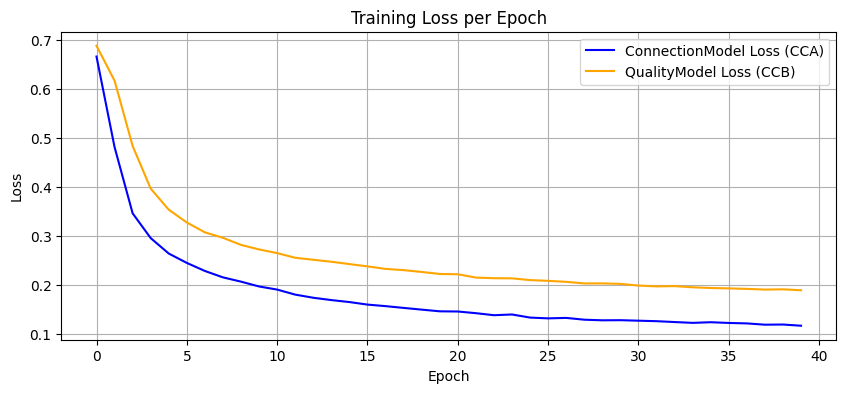

In [6]:
import matplotlib.pyplot as plt

# Loss 시각화
plt.figure(figsize=(10, 4))
plt.plot(history_conn["loss"], label="ConnectionModel Loss (CCA)", color='blue')
plt.plot(history_qual["loss"], label="QualityModel Loss (CCB)", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Model Saving & Loading

In [7]:
# Save trained model weights
torch.save(conn_model.state_dict(), "conn_model.pth")
torch.save(qual_model.state_dict(), "qual_model.pth")
print("Models saved to disk.")

# (Example of loading models - if needed later)
# conn_model_loaded = ConnectionModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)
# qual_model_loaded = QualityModel(n_users, n_items, EMB_DIM, N_LAYERS).to(device)
# conn_model_loaded.load_state_dict(torch.load("conn_model.pth"))
# qual_model_loaded.load_state_dict(torch.load("qual_model.pth"))
# conn_model_loaded.eval()
# qual_model_loaded.eval()


Models saved to disk.


# Testing Evaluation & Recommendation Results (임의)

In [8]:
# Prepare for evaluation: compute full embedding matrices one time:contentReference[oaicite:14]{index=14}
conn_model.eval()
qual_model.eval()
with torch.no_grad():
    user_emb_conn_all, item_emb_conn_all = conn_model(edge_index, edge_weight_conn)
    user_emb_qual_all, item_emb_qual_all = qual_model(edge_index, edge_weight_qual)

# Define normalization function to scale scores between 0 and 1
# (Use 1st to 99th percentile for connection scores, and [0.5, 5.0] range for quality scores as fixed):contentReference[oaicite:15]{index=15}
conn_scores = []
qual_scores = []
with torch.no_grad():
    # Compute scores for all training pairs to estimate distribution
    BATCH = 4096
    for start in range(0, len(train_df), BATCH):
        end = min(start + BATCH, len(train_df))
        u_idx_batch = torch.LongTensor(train_df["user_idx"].values[start:end]).to(device)
        i_idx_batch = torch.LongTensor(train_df["item_idx"].values[start:end]).to(device)
        s_conn = (user_emb_conn_all[u_idx_batch] * item_emb_conn_all[i_idx_batch]).sum(dim=-1).cpu().numpy()
        s_qual = qual_model.predict_score(u_idx_batch, i_idx_batch, edge_index, edge_weight_qual).cpu().numpy()
        conn_scores.append(s_conn)
        qual_scores.append(s_qual)
conn_scores = np.concatenate(conn_scores)
qual_scores = np.concatenate(qual_scores)
# Determine score normalization bounds
CCA_MIN, CCA_MAX = np.percentile(conn_scores, 1), np.percentile(conn_scores, 99)
CCB_MIN, CCB_MAX = 0.5, 5.0  # quality model outputs are in [0.5, 5.0] by design
def normalize(x, min_val, max_val):
    return np.clip((x - min_val) / (max_val - min_val + 1e-8), 0.0, 1.0)

# Determine ensemble weight (alpha) via validation set, if available:contentReference[oaicite:16]{index=16}
best_alpha = 0.5
if len(val_df) > 0:
    # Create validation positive and negative samples
    val_pos_u = val_df["user_idx"].values
    val_pos_i = val_df["item_idx"].values
    # sample equal number of negative pairs not in train
    known_edges = set(zip(train_df["user_idx"], train_df["item_idx"]))
    val_neg_u = []
    val_neg_i = []
    for _ in range(len(val_df)):
        while True:
            u_rand = np.random.randint(0, n_users)
            i_rand = np.random.randint(0, n_items)
            if (u_rand, i_rand) not in known_edges:
                val_neg_u.append(u_rand); val_neg_i.append(i_rand); break
    val_pos_u = torch.LongTensor(val_pos_u).to(device)
    val_pos_i = torch.LongTensor(val_pos_i).to(device)
    val_neg_u = torch.LongTensor(val_neg_u).to(device)
    val_neg_i = torch.LongTensor(val_neg_i).to(device)
    with torch.no_grad():
        # Compute scores for validation pairs
        conn_pos = (user_emb_conn_all[val_pos_u] * item_emb_conn_all[val_pos_i]).sum(dim=-1).cpu().numpy()
        conn_neg = (user_emb_conn_all[val_neg_u] * item_emb_conn_all[val_neg_i]).sum(dim=-1).cpu().numpy()
        qual_pos = qual_model.predict_score(val_pos_u, val_pos_i, edge_index, edge_weight_qual).cpu().numpy()
        qual_neg = qual_model.predict_score(val_neg_u, val_neg_i, edge_index, edge_weight_qual).cpu().numpy()
    # Normalize scores
    conn_pos_n = normalize(conn_pos, CCA_MIN, CCA_MAX)
    conn_neg_n = normalize(conn_neg, CCA_MIN, CCA_MAX)
    qual_pos_n = normalize(qual_pos, CCB_MIN, CCB_MAX)
    qual_neg_n = normalize(qual_neg, CCB_MIN, CCB_MAX)
    # Grid search for alpha that maximizes AUC on validation:contentReference[oaicite:17]{index=17}
    alphas = [0.3, 0.4, 0.5, 0.6, 0.7]
    best_auc = 0.0
    for alpha in alphas:
        beta = 1.0 - alpha
        scores = np.concatenate([alpha * conn_pos_n + beta * qual_pos_n,
                                 alpha * conn_neg_n + beta * qual_neg_n])
        labels = np.concatenate([np.ones_like(conn_pos_n), np.zeros_like(conn_neg_n)])
        auc_val = roc_auc_score(labels, scores)
        if auc_val > best_auc:
            best_auc = auc_val
            best_alpha = alpha
    print(f"Chosen alpha = {best_alpha:.2f} (val AUC = {best_auc:.4f})")
ALPHA = best_alpha
BETA = 1.0 - ALPHA

# Threshold tuning: find threshold that maximizes F1 on validation, while keeping recommend rate 20~50%:contentReference[oaicite:18]{index=18}:contentReference[oaicite:19]{index=19}
THRESHOLD = 0.5
if len(val_df) > 0:
    # Combine validation scores
    val_scores = np.concatenate([ALPHA * conn_pos_n + BETA * qual_pos_n,
                                 ALPHA * conn_neg_n + BETA * qual_neg_n])
    val_labels = np.concatenate([np.ones_like(conn_pos_n), np.zeros_like(conn_neg_n)])
    best_f1 = 0.0
    best_th = 0.0
    for th in np.linspace(val_scores.min(), val_scores.max(), 100):
        preds = (val_scores >= th).astype(int)
        o_ratio = preds.mean()
        if 0.2 <= o_ratio <= 0.5:  # only consider thresholds yielding 20%~50% positives:contentReference[oaicite:20]{index=20}
            f1_val = f1_score(val_labels, preds)
            if f1_val > best_f1:
                best_f1 = f1_val
                best_th = th
    THRESHOLD = best_th if best_th > 0 else THRESHOLD
    print(f"Chosen threshold = {THRESHOLD:.4f} (val F1 = {best_f1:.4f})")

# Prepare test queries (mix of actual test interactions and random negatives for evaluation)
test_queries = []
# Use up to 100 positive test pairs
num_test_samples = min(100, len(test_df))
if num_test_samples > 0:
    sample_idx = np.random.choice(len(test_df), size=num_test_samples, replace=False)
    for idx in sample_idx:
        u = test_df.iloc[idx]["user"]
        i = test_df.iloc[idx]["item"]
        test_queries.append((u, i))
# Add 100 random negative pairs (user-item pairs that did not occur in train)
neg_added = 0
known_edges = set(zip(train_df["user"], train_df["item"]))
while neg_added < 100:
    u_rand = df["user"].sample(1).iloc[0]
    i_rand = df["item"].sample(1).iloc[0]
    if (u_rand, i_rand) not in known_edges:
        test_queries.append((u_rand, i_rand))
        neg_added += 1

# Evaluate on test queries and output recommendations
results = []
with torch.no_grad():
    for user_id, item_id in test_queries:
        # Check if user or item is unknown (cold-start item or user not in training index maps)
        if user_id not in user2idx or item_id not in item2idx:
            results.append({"user": user_id, "item": item_id, "recommend": "X"})
            continue
        u_idx = user2idx[user_id]
        i_idx = item2idx[item_id]
        # Skip if item was already seen by user in training (we don't recommend already purchased items):contentReference[oaicite:21]{index=21}
        if i_idx in set(train_df[train_df["user_idx"] == u_idx]["item_idx"].values):
            results.append({"user": user_id, "item": item_id, "recommend": "X"})
            continue
        # Compute ensemble score for this user-item pair
        s_conn = (user_emb_conn_all[u_idx] * item_emb_conn_all[i_idx]).sum().item()
        s_qual = qual_model.predict_score(torch.tensor([u_idx], device=device),
                                          torch.tensor([i_idx], device=device),
                                          edge_index, edge_weight_qual).item()
        s_conn_n = normalize(s_conn, CCA_MIN, CCA_MAX)
        s_qual_n = normalize(s_qual, CCB_MIN, CCB_MAX)
        final_score = ALPHA * s_conn_n + BETA * s_qual_n
        # Determine recommendation using threshold and user-specific K limit:contentReference[oaicite:22]{index=22}:contentReference[oaicite:23]{index=23}
        # Check how many recommendations allowed for this user
        user_inter_count = len(train_df[train_df["user_idx"] == u_idx])
        K_user = 2 if user_inter_count <= 10 else max(1, int(0.2 * user_inter_count))
        # By threshold
        if final_score < THRESHOLD:
            # Below threshold -> Not recommended, unless cold-start user needs minimum recommendations
            # If user is cold (<=10 interactions) and final_score is below threshold, we will handle below
            recommend_flag = False
        else:
            recommend_flag = True
        # Enforce per-user recommendation count constraints:
        # Count how many of this user's queries have already been recommended in results
        rec_so_far = sum(1 for r in results if r["user"] == user_id and r["recommend"] == "O")
        if recommend_flag and rec_so_far < K_user:
            # Recommend (O) if score above threshold and user hasn't exceeded K recommendations
            results.append({"user": user_id, "item": item_id, "recommend": "O"})
        else:
            # If not recommending due to threshold or because user already has K recs
            # Special case: cold user with <=10 interactions should get at least 2 recommendations if possible
            if user_inter_count <= 10 and rec_so_far < 2:
                # Force recommend if this user hasn't received 2 recs yet (top items should be recommended):contentReference[oaicite:24]{index=24}
                results.append({"user": user_id, "item": item_id, "recommend": "O"})
            else:
                results.append({"user": user_id, "item": item_id, "recommend": "X"})
# Convert results to DataFrame and display
preds_df = pd.DataFrame(results)
total = len(preds_df)
rec_cnt = (preds_df["recommend"] == "O").sum()
not_cnt = total - rec_cnt
print("====================")
print(f"{'user':<10}{'item':<10}{'recommend':<10}")
for _, row in preds_df.iterrows():
    print(f"{str(row['user']):<10}{str(row['item']):<10}{row['recommend']:<10}")
print("====================")
print(f"Total recommends = {rec_cnt}/{total}")
print(f"Total not recommends = {not_cnt}/{total}")


Chosen alpha = 0.70 (val AUC = 0.7988)
Chosen threshold = 0.1462 (val F1 = 0.7693)
user      item      recommend 
780       273       O         
361       3715      O         
1396      870       O         
3897      4632      X         
3981      3820      O         
416       691       O         
1774      1843      O         
2742      41        O         
5013      5088      X         
3837      4304      O         
2296      2464      O         
3105      3099      O         
3897      4584      O         
570       657       X         
2045      3452      O         
5066      5071      O         
2404      1018      O         
856       3174      O         
3828      2063      O         
540       1566      O         
4291      905       O         
3366      3374      O         
4788      3429      O         
5655      5525      O         
35        3213      X         
2045      4608      O         
3854      3006      O         
3655      4611      O         
2070      1948    

# 테스트최종 (교수님이 주신 test파일)

In [10]:
import math
import torch
import pandas as pd

# 1. Load test.csv and ignore rating
test_df = pd.read_csv("test.csv")
if "rating" in test_df.columns:
    test_df = test_df.drop(columns=["rating"])

# 2. Map user/item to index
test_df["user_idx"] = test_df["user"].map(user2idx)
test_df["item_idx"] = test_df["item"].map(item2idx)

# 3. Fill unknown users/items with -1 (we will mark them as 'X')
test_df["user_idx"] = test_df["user_idx"].fillna(-1).astype(int)
test_df["item_idx"] = test_df["item_idx"].fillna(-1).astype(int)

results = []

# 4. Group by user for per-user recommendation constraint (K-user)
for user, group in test_df.groupby("user"):
    u_idx = group["user_idx"].iloc[0]

    # Case 1: Unknown user — all items marked X
    if u_idx == -1:
        for _, row in group.iterrows():
            results.append({"user": row["user"], "item": row["item"], "recommend": "X"})
        continue

    # Valid items only (item_idx != -1)
    valid_mask = group["item_idx"] != -1
    valid_group = group[valid_mask].reset_index()
    invalid_group = group[~valid_mask]

    i_idx_list = valid_group["item_idx"].tolist()
    user_tensor = torch.LongTensor([u_idx] * len(i_idx_list)).to(device)
    item_tensor = torch.LongTensor(i_idx_list).to(device)

    # Get user interaction count from train
    user_train_count = train_df[train_df["user_idx"] == u_idx].shape[0]
    if user_train_count <= 10:
        K_user = 2
    else:
        K_user = max(1, math.floor(user_train_count * 0.2))

    with torch.no_grad():
        conn_u_emb = user_emb_conn_all[user_tensor]
        conn_i_emb = item_emb_conn_all[item_tensor]
        s_conn = (conn_u_emb * conn_i_emb).sum(dim=-1).cpu().numpy()

        s_qual = qual_model.predict_score(user_tensor, item_tensor, edge_index, edge_weight_qual).cpu().numpy()

    # Normalize and combine scores
    s_conn_n = ((s_conn - CCA_MIN) / (CCA_MAX - CCA_MIN + 1e-8)).clip(0, 1)
    s_qual_n = ((s_qual - CCB_MIN) / (CCB_MAX - CCB_MIN + 1e-8)).clip(0, 1)
    final_scores = ALPHA * s_conn_n + BETA * s_qual_n

    above_idx = [i for i, score in enumerate(final_scores) if score >= THRESHOLD]

    if len(above_idx) == 0:
        # Nothing passes threshold: pick top-K_user
        top_k = min(K_user, len(final_scores))
        top_idx = final_scores.argsort()[-top_k:]
        selected_idx = set(top_idx)
    else:
        if len(above_idx) > K_user:
            scores_above = [final_scores[i] for i in above_idx]
            top_above_idx = sorted(range(len(scores_above)), key=lambda x: scores_above[x])[-K_user:]
            selected_idx = {above_idx[i] for i in top_above_idx}
        else:
            selected_idx = set(above_idx)
            if user_train_count <= 10 and len(selected_idx) < 2 and len(final_scores) >= 2:
                top_idx = final_scores.argsort()[-2:]
                selected_idx = set(top_idx)

    # Write recommend O/X for valid items
    for rel_idx, row in valid_group.iterrows():
        flag = "O" if rel_idx in selected_idx else "X"
        results.append({"user": row["user"], "item": row["item"], "recommend": flag})

    # Write recommend X for invalid items
    for _, row in invalid_group.iterrows():
        results.append({"user": row["user"], "item": row["item"], "recommend": "X"})

# 5. Output all results
preds_df = pd.DataFrame(results)
total = len(preds_df)
rec_cnt = (preds_df["recommend"] == "O").sum()
not_rec = total - rec_cnt

print("====================")
print(f"{'user':<7}{'item':<7}{'recommend':<10}")
for _, row in preds_df.iterrows():
    print(f"{str(row['user']):<7}{str(row['item']):<7}{row['recommend']:<10}")
print("====================")
print(f"Total recommends = {rec_cnt}/{total}")
print(f"Not recommend   = {not_rec}/{total}")


user   item   recommend 
1      17     O         
2      20     O         
2      1363   X         
2      167    O         
2      39     O         
2      223    O         
2      245    O         
4      492    O         
6      7      O         
7      6      O         
7      882    O         
7      1318   X         
10     25     O         
10     2      O         
10     3      X         
13     29     O         
21     2      O         
21     1      O         
21     10     X         
28     35     O         
35     1515   O         
35     2509   X         
35     2528   X         
36     2043   O         
41     265    O         
184    2028   O         
215    378    O         
241    1363   O         
257    295    O         
265    41     O         
266    1562   O         
309    149    O         
322    379    X         
363    202    O         
366    144    O         
378    215    O         
412    766    X         
416    634    O         
427    449    O         
